## Atividade 1

Number of samples: 239616
Signal duration: 9.9840 s
Sample rate: 24000 Hz
Input normalization: True


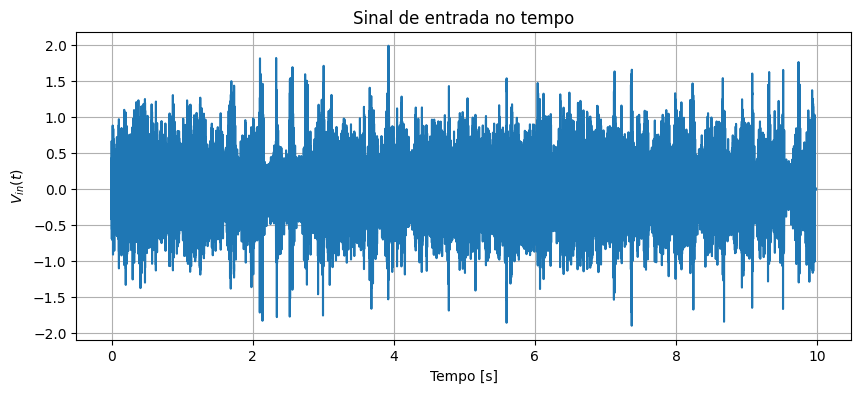

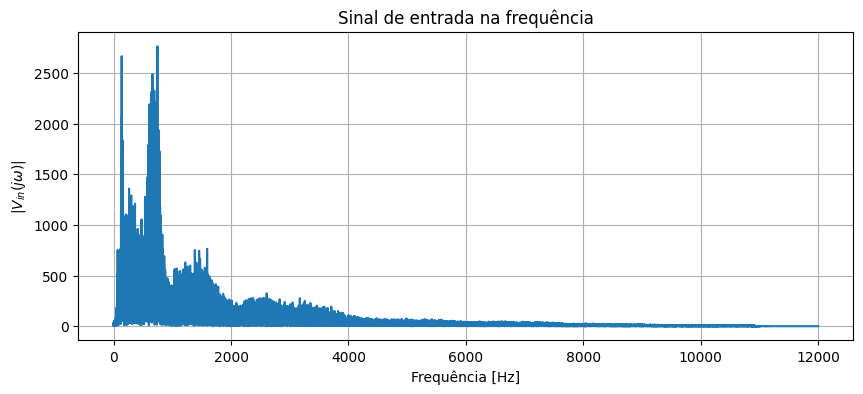

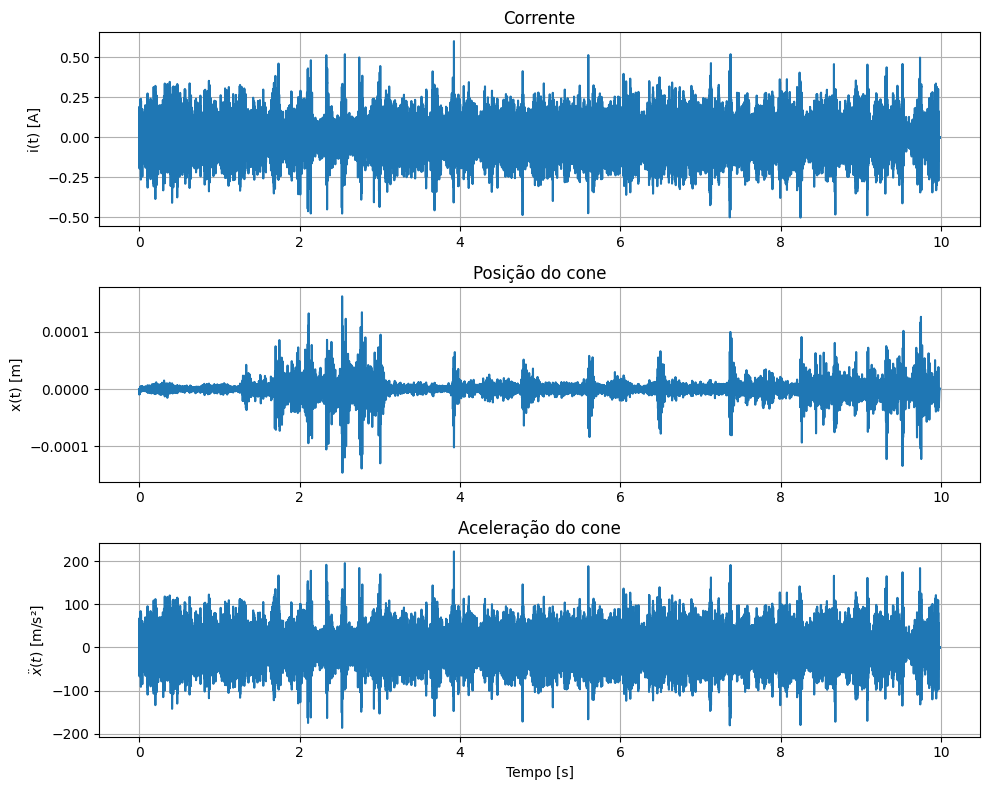

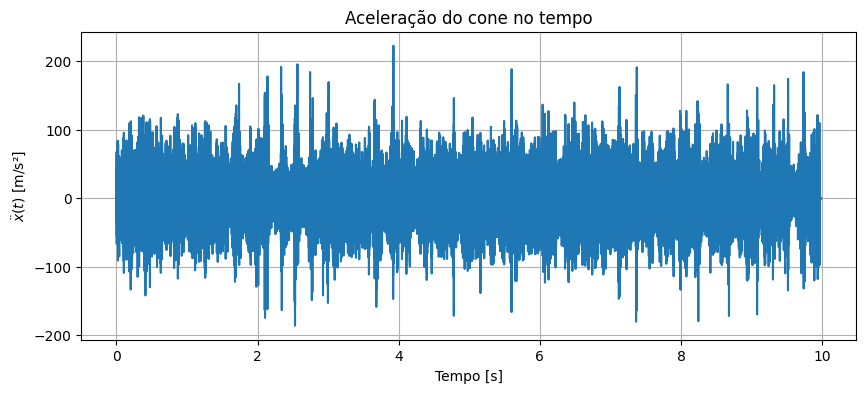

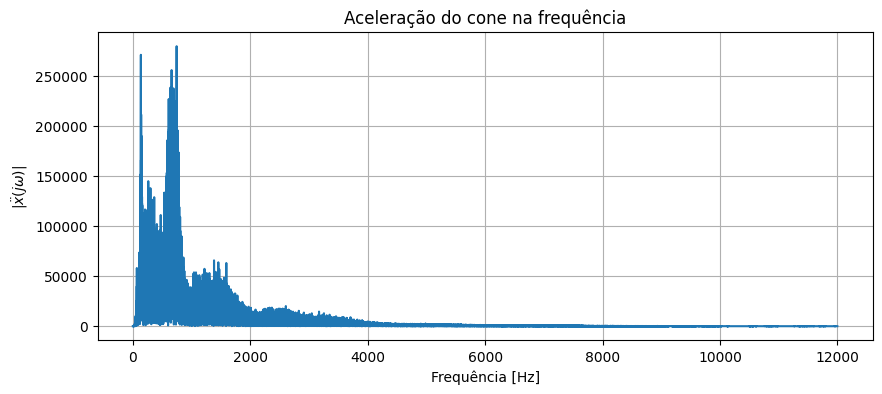

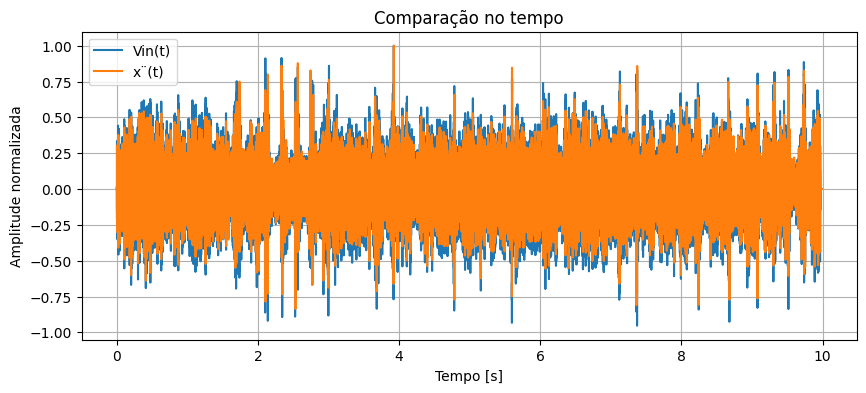

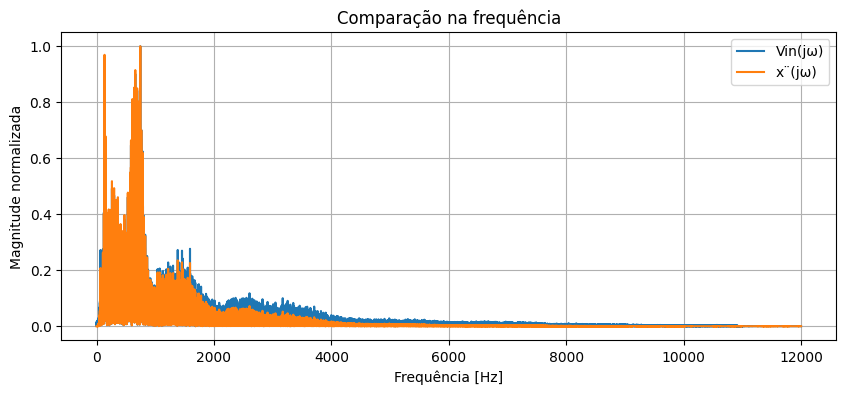

Arquivo salvo: TC02-out1.wav


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# =========================================================
# Configuração
# =========================================================
USE_INPUT_NORMALIZATION = True   # True = força |Vin| < 2.0 V
INPUT_VOLTAGE_LIMIT = 1.99       # valor de pico usado se normalizar

# =========================================================
# Leitura do arquivo
# =========================================================
sample_rate, data = wavfile.read('TC02-in.wav')
data = data.astype(float)

# Se estiver estéreo, usa apenas o canal 0
if data.ndim > 1:
    Vin = data[:, 0]
else:
    Vin = data

# Normalização opcional da entrada
if USE_INPUT_NORMALIZATION:
    Vin_max = np.max(np.abs(Vin))
    if Vin_max > 0:
        Vin = INPUT_VOLTAGE_LIMIT * Vin / Vin_max

# Vetor de tempo
num_samples = len(Vin)
duration = num_samples / sample_rate
time = np.arange(num_samples) / sample_rate

print(f"Number of samples: {num_samples}")
print(f"Signal duration: {duration:.4f} s")
print(f"Sample rate: {sample_rate} Hz")
print(f"Input normalization: {USE_INPUT_NORMALIZATION}")

# =========================================================
# Parâmetros do modelo linear
# =========================================================
m = 14.35e-3
b = 0.786
k = 1852
Bl = 4.95
L = 266e-6
R = 3.3

# =========================================================
# Matrizes de espaço de estados
# =========================================================
# Matriz A:
# descreve a dinâmica interna do sistema, ou seja,
# como as variáveis de estado [i, x, v] influenciam suas próprias derivadas [i_dot, x_dot, v_dot]
A = np.array([[-R/L,   0,   -Bl/L],   # i_dot depende de i e de v
              [0,      0,    1   ],   # x_dot = v
              [Bl/m, -k/m, -b/m  ]])  # v_dot depende de i, x e v

# Matriz B:
# define como a entrada u = Vin(t) entra no sistema
# aqui a tensão de entrada afeta diretamente apenas a equação da corrente
B = np.array([1/L, 0, 0])

# Matriz C:
# define qual variável do vetor de estado será escolhida como saída y(t)
# [0, 0, 1] significa que a saída escolhida é v, a velocidade do cone
C = np.array([0, 0, 1])

# Matriz identidade 3x3:
# normalmente usada em expressões no domínio da frequência,
# como em (jωI - A)^(-1)
I = np.eye(3)

# =========================================================
# Interpolação da entrada
# =========================================================
vin_interp = interp1d(time, Vin, bounds_error=False, fill_value=(Vin[0], Vin[-1]))

# =========================================================
# Modelo em espaço de estados
# =========================================================
def f(t, z):
    return A @ z + B * vin_interp(t)

# =========================================================
# Simulação
# =========================================================
sol = solve_ivp(f, [0, duration], [0, 0, 0], t_eval=time)

i = sol.y[0, :]
x = sol.y[1, :]
v = sol.y[2, :]
xdd = Bl/m * i - k/m * x - b/m * v

# =========================================================
# FFT
# =========================================================
N = len(Vin)
freq = np.fft.fftfreq(N, d=1/sample_rate)
idx = freq >= 0

Vin_fft = np.fft.fft(Vin)
xdd_fft = np.fft.fft(xdd)

# =========================================================
# Vin(t)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(time, Vin)
plt.xlabel('Tempo [s]')
plt.ylabel('$V_{in}(t)$')
plt.title('Sinal de entrada no tempo')
plt.grid(True)
plt.show()

# =========================================================
# Vin(jw)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(Vin_fft[idx]))
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|V_{in}(j\omega)|$')
plt.title('Sinal de entrada na frequência')
plt.grid(True)
plt.show()

# =========================================================
# i(t), x(t), x¨(t)
# =========================================================
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(sol.t, i)
plt.ylabel('i(t) [A]')
plt.title('Corrente')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(sol.t, x)
plt.ylabel('x(t) [m]')
plt.title('Posição do cone')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(sol.t, xdd)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone')
plt.grid(True)

plt.tight_layout()
plt.show()

# =========================================================
# x¨(t)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(sol.t, xdd)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone no tempo')
plt.grid(True)
plt.show()

# =========================================================
# x¨(jw)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(xdd_fft[idx]))
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|\ddot{x}(j\omega)|$')
plt.title('Aceleração do cone na frequência')
plt.grid(True)
plt.show()

# =========================================================
# Comparação no tempo
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(time, Vin / np.max(np.abs(Vin)), label='Vin(t)')
plt.plot(time, xdd / np.max(np.abs(xdd)), label='x¨(t)')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude normalizada')
plt.title('Comparação no tempo')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Comparação na frequência
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(Vin_fft[idx]) / np.max(np.abs(Vin_fft[idx])), label='Vin(jω)')
plt.plot(freq[idx], np.abs(xdd_fft[idx]) / np.max(np.abs(xdd_fft[idx])), label='x¨(jω)')
plt.xlabel('Frequência [Hz]')
plt.ylabel('Magnitude normalizada')
plt.title('Comparação na frequência')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Salvar saída
# =========================================================
out = xdd.copy()
out_max = np.max(np.abs(out))
if out_max > 0:
    out = out / out_max

wavfile.write('TC02-out1.wav', sample_rate, out.astype(np.float32))
print('Arquivo salvo: TC02-out1.wav')

## Atividade 2

Number of samples: 239616
Signal duration: 9.9840 s
Sample rate: 24000 Hz
Input normalization: True
x_max = 1.617548e-04 m
x1    = 8.087738e-06 m
x2    = 3.235095e-05 m


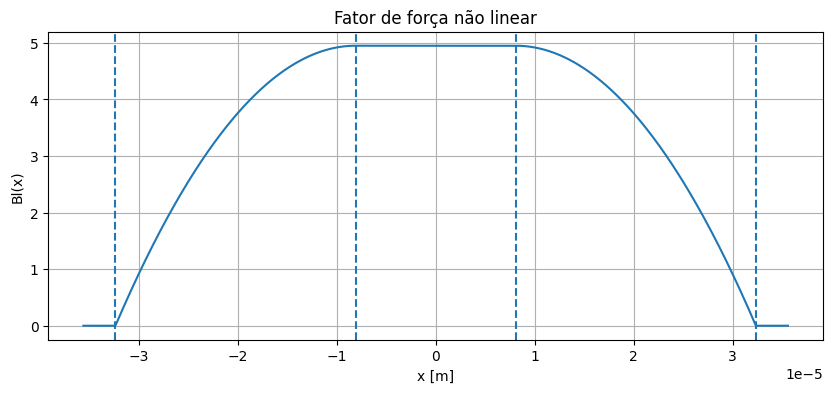

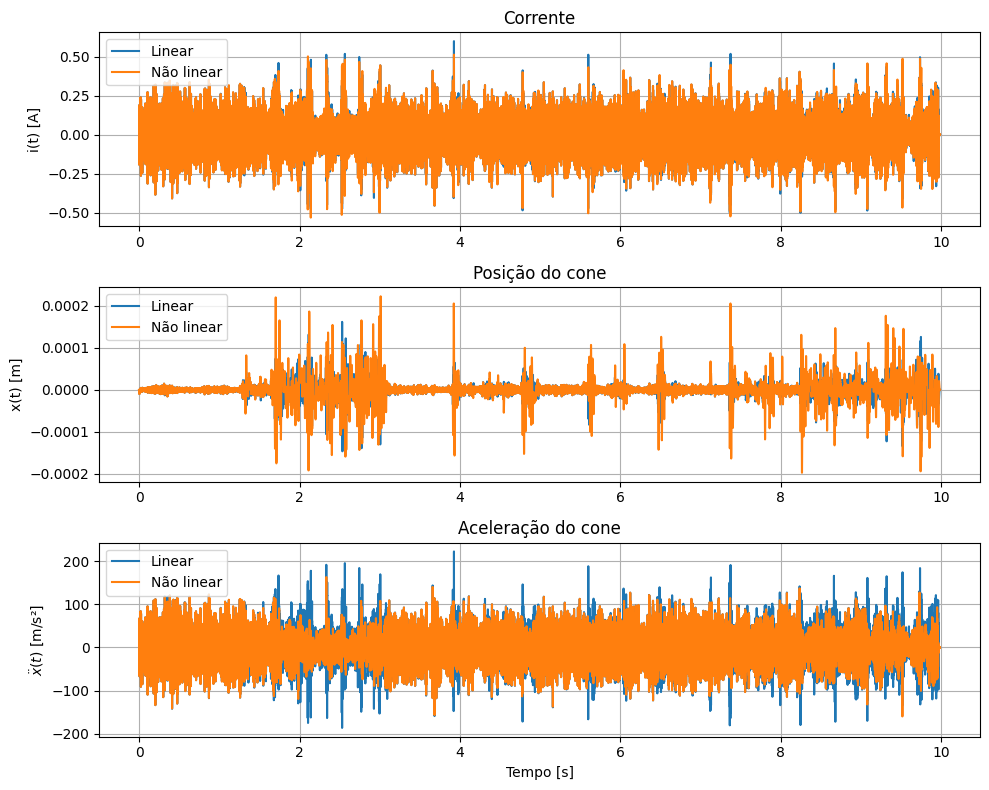

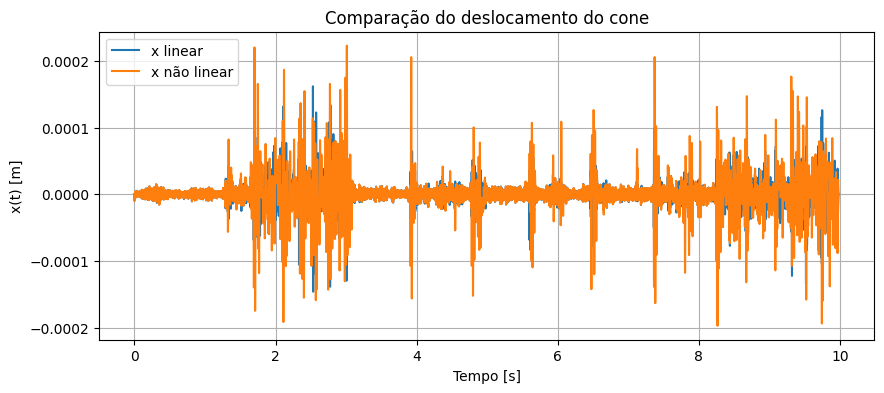

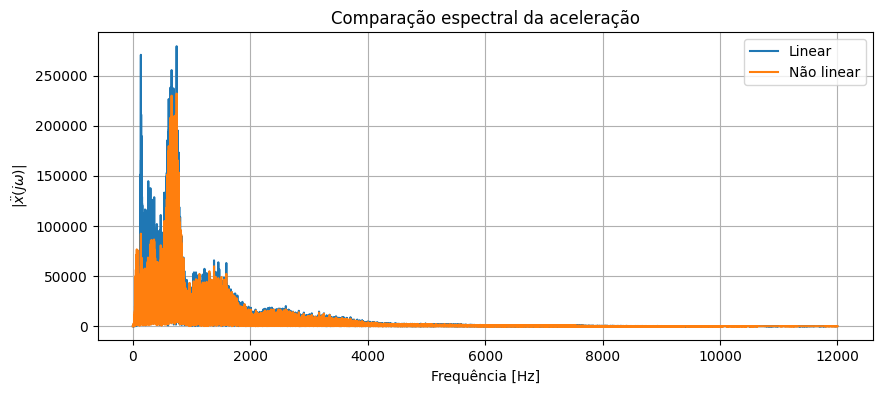

Arquivo salvo: TC02-out2.wav


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# =========================================================
# Configuração
# =========================================================
USE_INPUT_NORMALIZATION = True
INPUT_VOLTAGE_LIMIT = 1.99

# =========================================================
# Leitura do arquivo
# =========================================================
sample_rate, data = wavfile.read('TC02-in.wav')
data = data.astype(float)

# Se estiver estéreo, usa apenas o canal 0
if data.ndim > 1:
    Vin = data[:, 0]
else:
    Vin = data

# Normalização opcional da entrada
if USE_INPUT_NORMALIZATION:
    Vin_max = np.max(np.abs(Vin))
    if Vin_max > 0:
        Vin = INPUT_VOLTAGE_LIMIT * Vin / Vin_max

# Vetor de tempo
num_samples = len(Vin)
duration = num_samples / sample_rate
time = np.arange(num_samples) / sample_rate

print(f"Number of samples: {num_samples}")
print(f"Signal duration: {duration:.4f} s")
print(f"Sample rate: {sample_rate} Hz")
print(f"Input normalization: {USE_INPUT_NORMALIZATION}")

# =========================================================
# Parâmetros do modelo linear
# =========================================================
m = 14.35e-3
b = 0.786
k = 1852
Bl = 4.95
L = 266e-6
R = 3.3

# =========================================================
# Entrada interpolada
# =========================================================
vin_interp = interp1d(time, Vin, bounds_error=False, fill_value=(Vin[0], Vin[-1]))

# =========================================================
# MODELO LINEAR
# =========================================================
A = np.array([[-R/L,   0,   -Bl/L],
              [0,      0,    1   ],
              [Bl/m, -k/m, -b/m  ]])

B = np.array([1/L, 0, 0])

def f_linear(t, z):
    return A @ z + B * vin_interp(t)

sol_linear = solve_ivp(f_linear, [0, duration], [0, 0, 0], t_eval=time)

i_linear = sol_linear.y[0, :]
x_linear = sol_linear.y[1, :]
v_linear = sol_linear.y[2, :]
xdd_linear = Bl/m * i_linear - k/m * x_linear - b/m * v_linear

# =========================================================
# ATIVIDADE 02 - definir x1 e x2 a partir do modelo linear
# =========================================================
x_max = np.max(np.abs(x_linear))
x1 = 0.05 * x_max
x2 = 0.20 * x_max

print(f"x_max = {x_max:.6e} m")
print(f"x1    = {x1:.6e} m")
print(f"x2    = {x2:.6e} m")

# =========================================================
# Bl não linear
# |x| <= x1  -> Bl constante
# |x| >= x2  -> Bl = 0
# x1 < |x| < x2 -> decaimento polinomial de ordem 2
# =========================================================
def Bl_nonlinear(xpos):
    absx = np.abs(xpos)

    if absx <= x1:
        return Bl
    elif absx >= x2:
        return 0.0
    else:
        s = (absx - x1) / (x2 - x1)   # s varia de 0 até 1
        return Bl * (1.0 - s**2)      # polinômio de ordem 2

# =========================================================
# MODELO NÃO LINEAR
# =========================================================
def f_nonlinear(t, z):
    i = z[0]
    xpos = z[1]
    v = z[2]

    Blx = Bl_nonlinear(xpos)
    u = vin_interp(t)

    di_dt = (-R * i - Blx * v + u) / L
    dx_dt = v
    dv_dt = (Blx * i - k * xpos - b * v) / m

    return np.array([di_dt, dx_dt, dv_dt])

sol_nl = solve_ivp(f_nonlinear, [0, duration], [0, 0, 0], t_eval=time)

i_nl = sol_nl.y[0, :]
x_nl = sol_nl.y[1, :]
v_nl = sol_nl.y[2, :]

# Bl(x) avaliado ao longo da trajetória não linear
Bl_nl_vals = np.array([Bl_nonlinear(xpos) for xpos in x_nl])

# Aceleração não linear
xdd_nl = Bl_nl_vals / m * i_nl - k/m * x_nl - b/m * v_nl

# =========================================================
# Gráfico de Bl(x)
# =========================================================
x_plot = np.linspace(-1.1 * x2, 1.1 * x2, 1000)
Bl_plot = np.array([Bl_nonlinear(xp) for xp in x_plot])

plt.figure(figsize=(10, 4))
plt.plot(x_plot, Bl_plot)
plt.axvline(-x2, linestyle='--')
plt.axvline(-x1, linestyle='--')
plt.axvline(x1, linestyle='--')
plt.axvline(x2, linestyle='--')
plt.xlabel('x [m]')
plt.ylabel('Bl(x)')
plt.title('Fator de força não linear')
plt.grid(True)
plt.show()

# =========================================================
# Comparação linear vs não linear no tempo
# =========================================================
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(time, i_linear, label='Linear')
plt.plot(time, i_nl, label='Não linear')
plt.ylabel('i(t) [A]')
plt.title('Corrente')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time, x_linear, label='Linear')
plt.plot(time, x_nl, label='Não linear')
plt.ylabel('x(t) [m]')
plt.title('Posição do cone')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time, xdd_linear, label='Linear')
plt.plot(time, xdd_nl, label='Não linear')
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# Comparação do deslocamento
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(time, x_linear, label='x linear')
plt.plot(time, x_nl, label='x não linear')
plt.xlabel('Tempo [s]')
plt.ylabel('x(t) [m]')
plt.title('Comparação do deslocamento do cone')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# FFT da aceleração não linear
# =========================================================
N = len(Vin)
freq = np.fft.fftfreq(N, d=1/sample_rate)
idx = freq >= 0

xdd_nl_fft = np.fft.fft(xdd_nl)
xdd_linear_fft = np.fft.fft(xdd_linear)

plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(xdd_linear_fft[idx]), label='Linear')
plt.plot(freq[idx], np.abs(xdd_nl_fft[idx]), label='Não linear')
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|\ddot{x}(j\omega)|$')
plt.title('Comparação espectral da aceleração')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Salvar saída não linear
# =========================================================
out2 = xdd_nl.copy()
out2_max = np.max(np.abs(out2))
if out2_max > 0:
    out2 = out2 / out2_max

wavfile.write('TC02-out2.wav', sample_rate, out2.astype(np.float32))
print('Arquivo salvo: TC02-out2.wav')